In [1]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn', 'scikit-learn', 
                'pandas', 'numpy', 'matplotlib', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid")
save_path = '/home/azureuser/cloudfiles/code/Users/aazartaheri/'

# Load all datasets
df = pd.read_csv(f'{save_path}bank_clean.csv')
df_seg = pd.read_csv(f'{save_path}bank_segmented.csv')

# Load model results
with open(f'{save_path}model_results.json', 'r') as f:
    results = json.load(f)

print("✅ Everything loaded!")
print(f"Model Results: {results}")

✅ Everything loaded!
Model Results: {'logistic_regression_auc': 0.8558, 'random_forest_auc': 0.9, 'best_model': 'Random Forest', 'test_set_size': 1569, 'features_used': ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'Cluster']}


##  Executive Dashboard

/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128273 (\N{KEY}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4501/4206718913.py:125: UserWarning: Glyph 128201 (\N{C

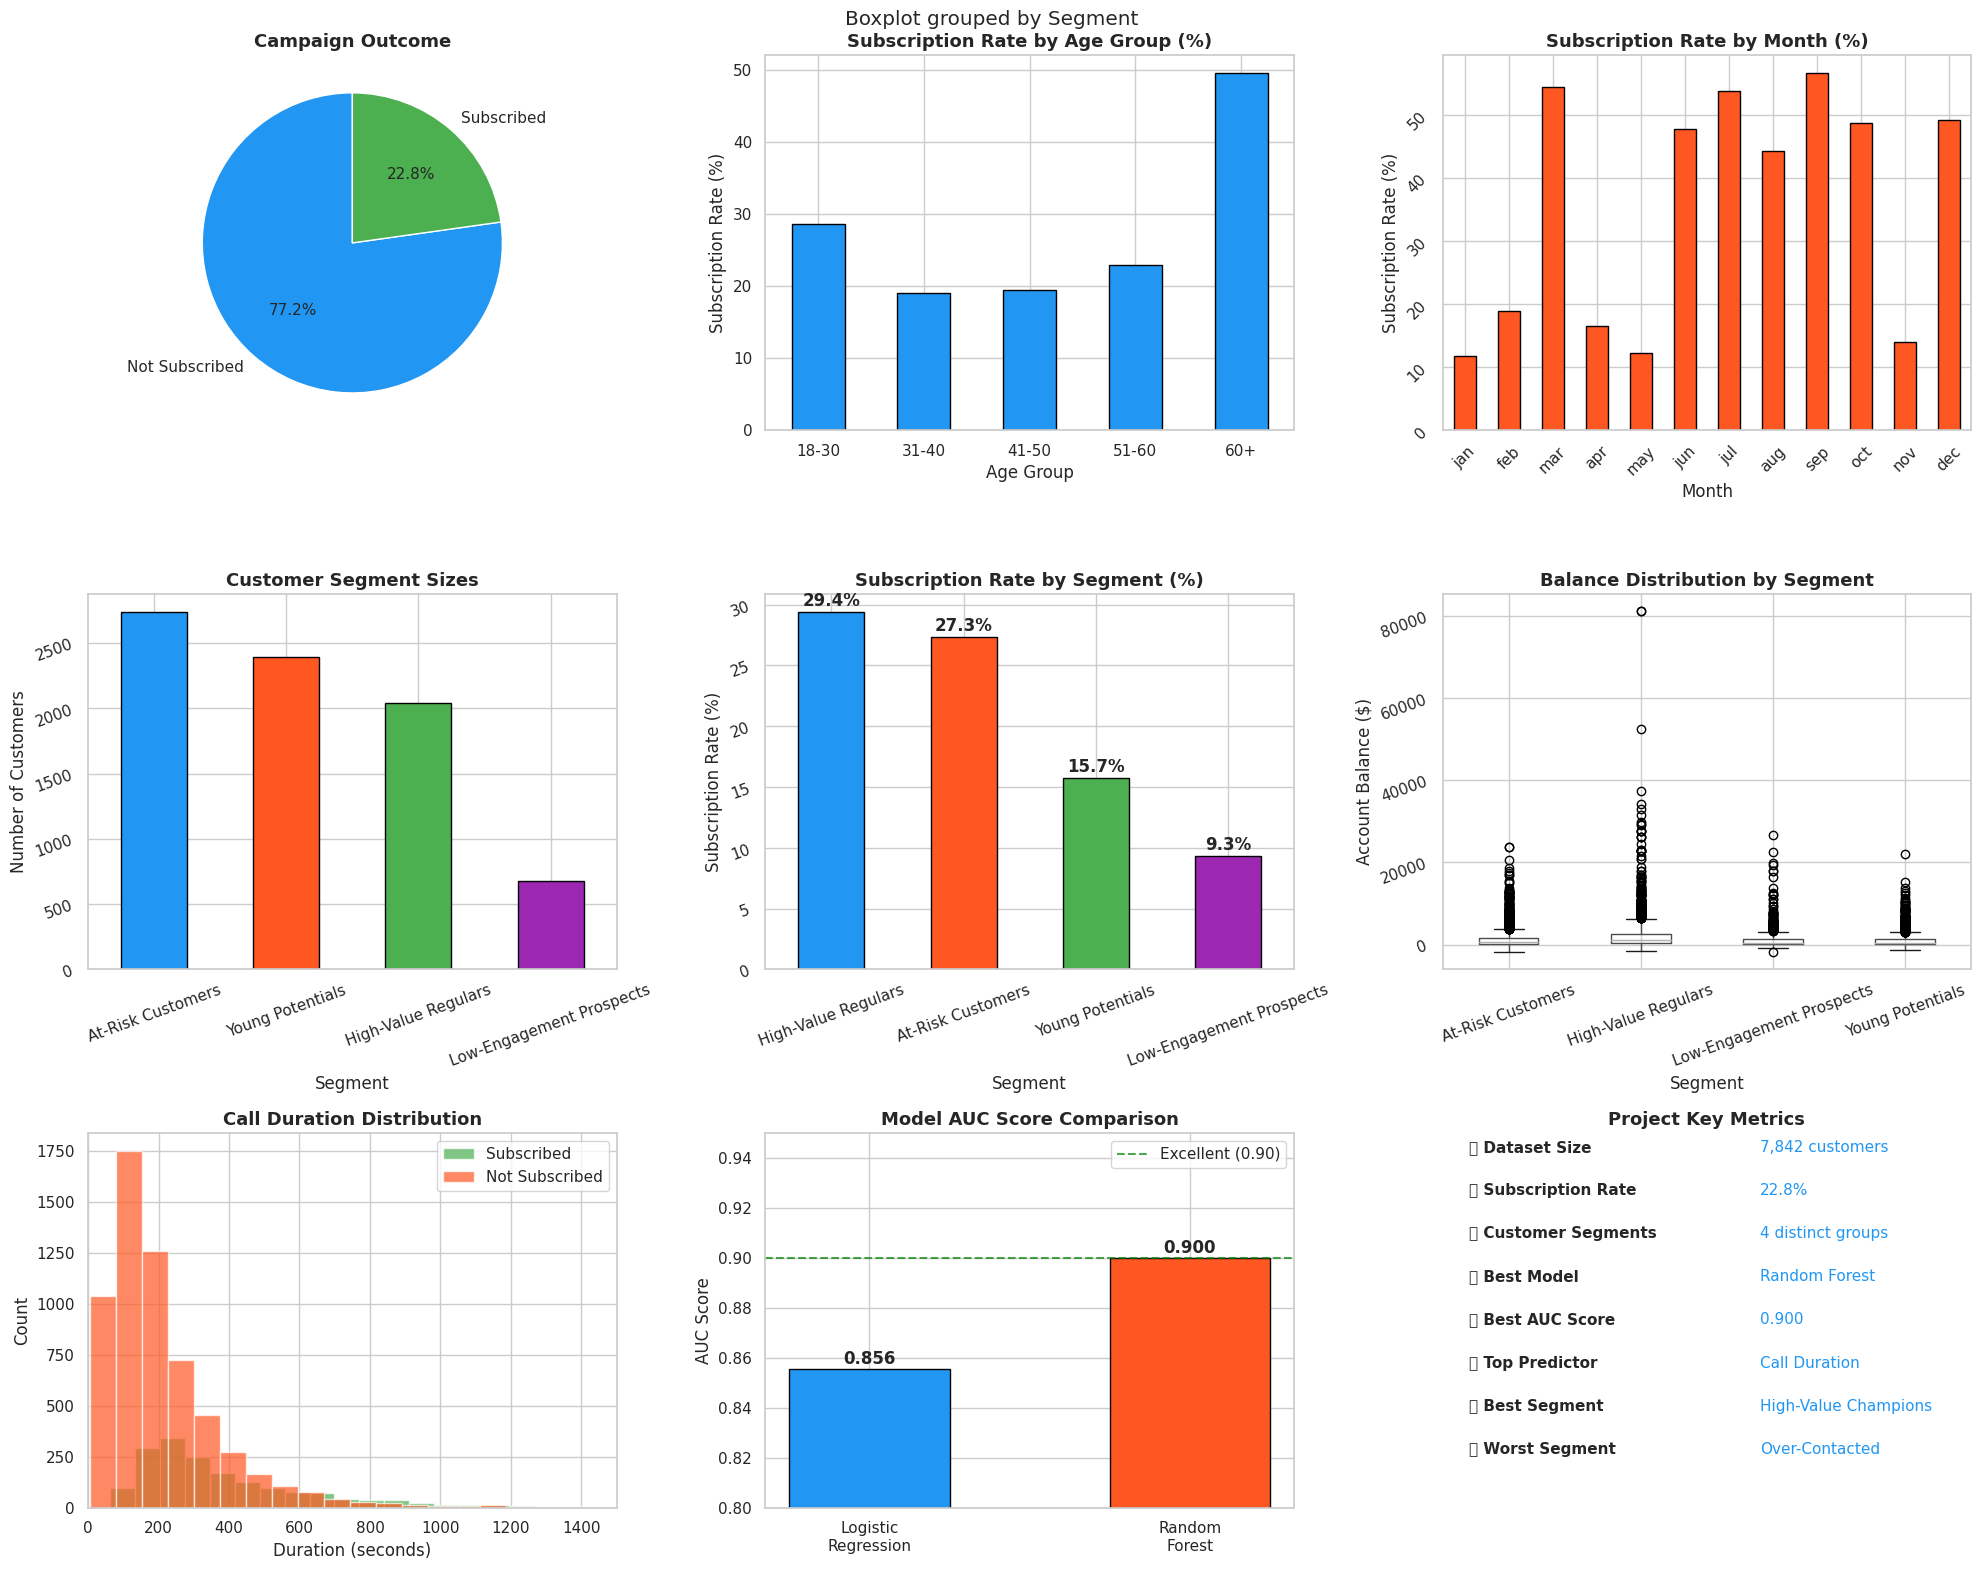

✅ Executive Dashboard saved!


In [3]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Bank Marketing Campaign — Executive Dashboard', 
             fontsize=22, fontweight='bold', y=0.98)

# Color palette
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

# ── Chart 1: Subscription Outcome (top left)
ax1 = fig.add_subplot(3, 3, 1)
outcome_counts = df['y'].value_counts()
wedges, texts, autotexts = ax1.pie(
    outcome_counts, labels=['Not Subscribed', 'Subscribed'],
    colors=['#2196F3', '#4CAF50'], autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 11})
ax1.set_title('Campaign Outcome', fontsize=13, fontweight='bold')

# ── Chart 2: Subscription by Age Group (top middle)
ax2 = fig.add_subplot(3, 3, 2)
df['age_group'] = pd.cut(df['age'], 
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_sub = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x=='yes').sum()/len(x)*100)
age_sub.plot(kind='bar', ax=ax2, color='#2196F3', edgecolor='black')
ax2.set_title('Subscription Rate by Age Group (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Subscription Rate (%)')
ax2.tick_params(rotation=0)

# ── Chart 3: Subscription by Month (top right)
ax3 = fig.add_subplot(3, 3, 3)
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_sub = df.groupby('month')['y'].apply(
    lambda x: (x=='yes').sum()/len(x)*100)
month_sub = month_sub.reindex(
    [m for m in month_order if m in month_sub.index])
month_sub.plot(kind='bar', ax=ax3, color='#FF5722', edgecolor='black')
ax3.set_title('Subscription Rate by Month (%)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Subscription Rate (%)')
ax3.tick_params(rotation=45)

# ── Chart 4: Customer Segments (middle left)
ax4 = fig.add_subplot(3, 3, 4)
seg_counts = df_seg['Segment'].value_counts()
seg_counts.plot(kind='bar', ax=ax4, color=colors, edgecolor='black')
ax4.set_title('Customer Segment Sizes', fontsize=13, fontweight='bold')
ax4.set_xlabel('Segment')
ax4.set_ylabel('Number of Customers')
ax4.tick_params(rotation=20)

# ── Chart 5: Subscription Rate per Segment (middle center)
ax5 = fig.add_subplot(3, 3, 5)
seg_sub = df_seg.groupby('Segment')['y'].apply(
    lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
bars = seg_sub.plot(kind='bar', ax=ax5, color=colors, edgecolor='black')
ax5.set_title('Subscription Rate by Segment (%)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Segment')
ax5.set_ylabel('Subscription Rate (%)')
ax5.tick_params(rotation=20)
for i, v in enumerate(seg_sub):
    ax5.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 6: Balance by Segment (middle right)
ax6 = fig.add_subplot(3, 3, 6)
df_seg.boxplot(column='balance', by='Segment', ax=ax6)
ax6.set_title('Balance Distribution by Segment', fontsize=13, fontweight='bold')
ax6.set_xlabel('Segment')
ax6.set_ylabel('Account Balance ($)')
ax6.tick_params(rotation=20)
plt.sca(ax6)
plt.title('Balance Distribution by Segment', fontsize=13, fontweight='bold')

# ── Chart 7: Call Duration Impact (bottom left)
ax7 = fig.add_subplot(3, 3, 7)
df_yes = df[df['y']=='yes']['duration']
df_no = df[df['y']=='no']['duration']
ax7.hist(df_yes, bins=30, alpha=0.7, color='#4CAF50', label='Subscribed')
ax7.hist(df_no, bins=30, alpha=0.7, color='#FF5722', label='Not Subscribed')
ax7.set_title('Call Duration Distribution', fontsize=13, fontweight='bold')
ax7.set_xlabel('Duration (seconds)')
ax7.set_ylabel('Count')
ax7.legend()
ax7.set_xlim(0, 1500)

# ── Chart 8: Model Performance (bottom center)
ax8 = fig.add_subplot(3, 3, 8)
models = ['Logistic\nRegression', 'Random\nForest']
aucs = [results['logistic_regression_auc'], results['random_forest_auc']]
bars = ax8.bar(models, aucs, color=['#2196F3', '#FF5722'], 
               edgecolor='black', width=0.5)
ax8.set_title('Model AUC Score Comparison', fontsize=13, fontweight='bold')
ax8.set_ylabel('AUC Score')
ax8.set_ylim(0.8, 0.95)
for bar, auc in zip(bars, aucs):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{auc:.3f}', ha='center', fontweight='bold', fontsize=12)
ax8.axhline(y=0.9, color='green', linestyle='--', 
            label='Excellent (0.90)', alpha=0.7)
ax8.legend()

# ── Chart 9: Key Metrics Summary (bottom right)
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
metrics_text = [
    ('📊 Dataset Size', f"{len(df):,} customers"),
    ('🎯 Subscription Rate', f"{(df['y']=='yes').mean()*100:.1f}%"),
    ('👥 Customer Segments', '4 distinct groups'),
    ('🏆 Best Model', 'Random Forest'),
    ('📈 Best AUC Score', f"{results['random_forest_auc']:.3f}"),
    ('🔑 Top Predictor', 'Call Duration'),
    ('💡 Best Segment', 'High-Value Champions'),
    ('📉 Worst Segment', 'Over-Contacted'),
]
y_pos = 0.95
for label, value in metrics_text:
    ax9.text(0.05, y_pos, label, fontsize=11, fontweight='bold',
             transform=ax9.transAxes)
    ax9.text(0.6, y_pos, value, fontsize=11,
             transform=ax9.transAxes, color='#2196F3')
    y_pos -= 0.115
ax9.set_title('Project Key Metrics', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Executive Dashboard saved!")

## **Marketing Recommendations Chart**

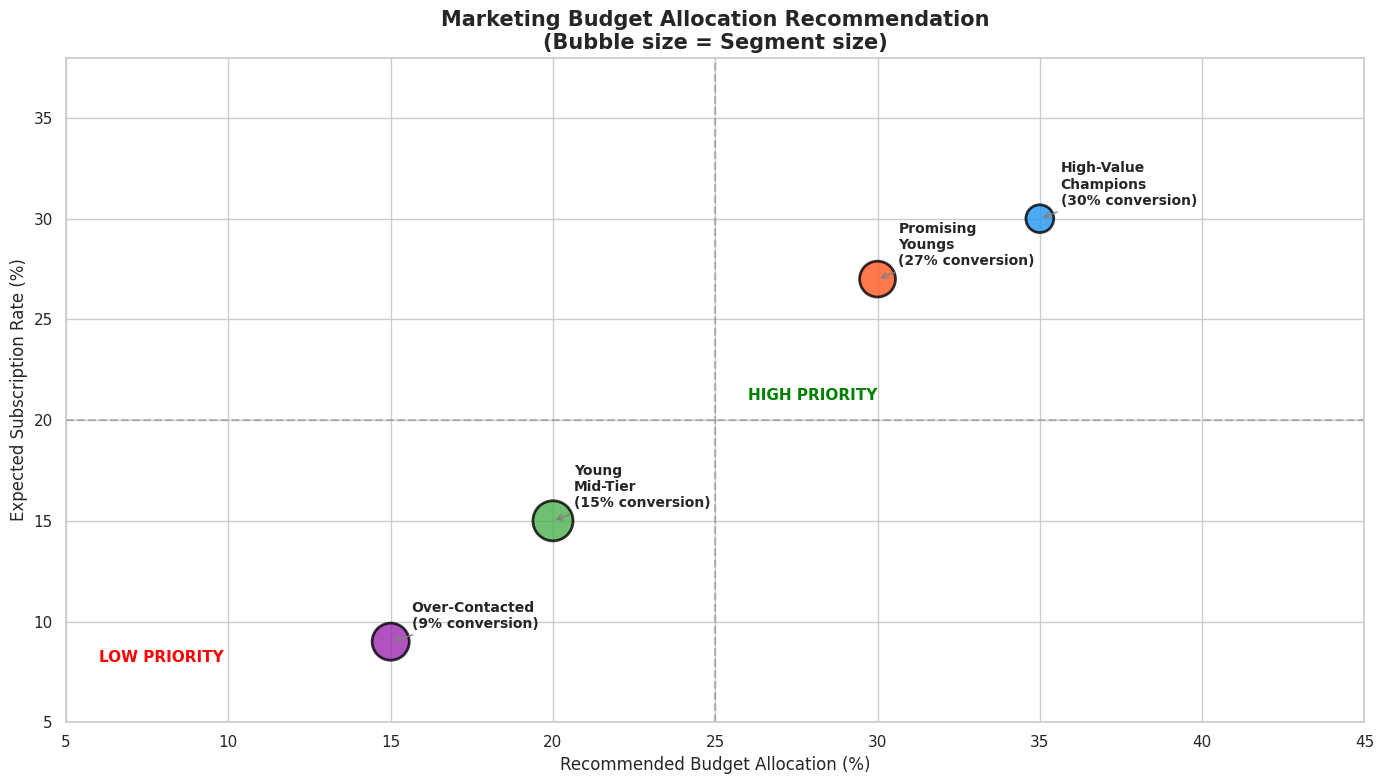

✅ Marketing recommendations chart saved!


In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

segments = ['High-Value\nChampions', 'Promising\nYoungs', 
            'Young\nMid-Tier', 'Over-Contacted']
sub_rates = [30, 27, 15, 9]
budgets = [35, 30, 20, 15]
sizes = [1200, 2000, 2500, 2142]

scatter = ax.scatter(budgets, sub_rates, s=[s/3 for s in sizes],
                     c=colors, alpha=0.8, edgecolors='black', linewidth=2)

for i, seg in enumerate(segments):
    ax.annotate(f'{seg}\n({sub_rates[i]}% conversion)',
                (budgets[i], sub_rates[i]),
                textcoords="offset points",
                xytext=(15, 10), fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Marketing Budget Allocation Recommendation\n(Bubble size = Segment size)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Recommended Budget Allocation (%)', fontsize=12)
ax.set_ylabel('Expected Subscription Rate (%)', fontsize=12)
ax.set_xlim(5, 45)
ax.set_ylim(5, 38)

# Add quadrant lines
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=25, color='gray', linestyle='--', alpha=0.5)
ax.text(26, 21, 'HIGH PRIORITY', fontsize=11, color='green', fontweight='bold')
ax.text(6, 8, 'LOW PRIORITY', fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_path}marketing_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Marketing recommendations chart saved!")

In [5]:
import os
print("📁 All project files saved:")
for f in sorted(os.listdir(save_path)):
    size = os.path.getsize(f'{save_path}{f}')
    print(f"  ✅ {f} ({size/1024:.1f} KB)")

📁 All project files saved:
  ✅ .amlignore (0.3 KB)
  ✅ .amlignore.amltmp (0.3 KB)
  ✅ .ipynb_aml_checkpoints (0.0 KB)
  ✅ 01_data_cleaning_EDA.ipynb (456.8 KB)
  ✅ 01_data_cleaning_eda.ipynb.amltmp (456.8 KB)
  ✅ 02_customer_segmentation.ipynb (409.5 KB)
  ✅ 02_customer_segmentation.ipynb.amltmp (409.5 KB)
  ✅ 03_churn_prediction_model.ipynb (163.8 KB)
  ✅ 03_churn_prediction_model.ipynb.amltmp (163.8 KB)
  ✅ 04_visualizations.ipynb (480.9 KB)
  ✅ 04_visualizations.ipynb.amltmp (480.9 KB)
  ✅ bank-full.csv (4502.3 KB)
  ✅ bank_clean.csv (634.0 KB)
  ✅ bank_encoded.csv (319.4 KB)
  ✅ bank_segmented.csv (531.9 KB)
  ✅ campaign_analysis.png (83.2 KB)
  ✅ campaign_overview.png (57.0 KB)
  ✅ cluster_pca.png (294.4 KB)
  ✅ cluster_profiles.png (117.9 KB)
  ✅ correlation_heatmap.png (318.2 KB)
  ✅ elbow_curve.png (102.3 KB)
  ✅ executive_dashboard.png (445.2 KB)
  ✅ marketing_recommendations.png (126.8 KB)
  ✅ model_comparison.png (180.4 KB)
  ✅ model_results.json (0.4 KB)
  ✅ rf_model.pkl (1